<a href="https://colab.research.google.com/github/paramveer00758/summer-training/blob/main/Week1project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")

# Load dataset directly from a dependable public source
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Data Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded successfully!
Data Shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Task 3: Data Cleaning

# 1. Check for missing values
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# 2. Handle missing values
# Fill missing Age with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop 'Cabin' column due to excessive missing data
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# 3. Remove duplicates
df.drop_duplicates(inplace=True)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Task 3: Data Cleaning

# 1. Check for missing values
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# 2. Handle missing values
# Fill missing Age with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop 'Cabin' column due to excessive missing data
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# 3. Remove duplicates
df.drop_duplicates(inplace=True)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values Before Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Task 4: Data Manipulation

# Create a new feature: FamilySize (SibSp + Parch + 1 for themselves)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create an indicator feature: IsAlone (1 if traveling alone, 0 otherwise)
df['IsAlone'] = df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

print("--- Sample of Manipulated Data ---")
df[['Name', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

--- Statistical Summary ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


/tmp/ipykernel_14929/635222452.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
/tmp/ipykernel_14929/635222452.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Did Not Survive', 'Survived'])
/tmp/ipykernel_14929/635222452.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', ax=axes[1], palette='pastel', ci=None)
/tmp/ipykernel_14929/635222452.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', ax=a

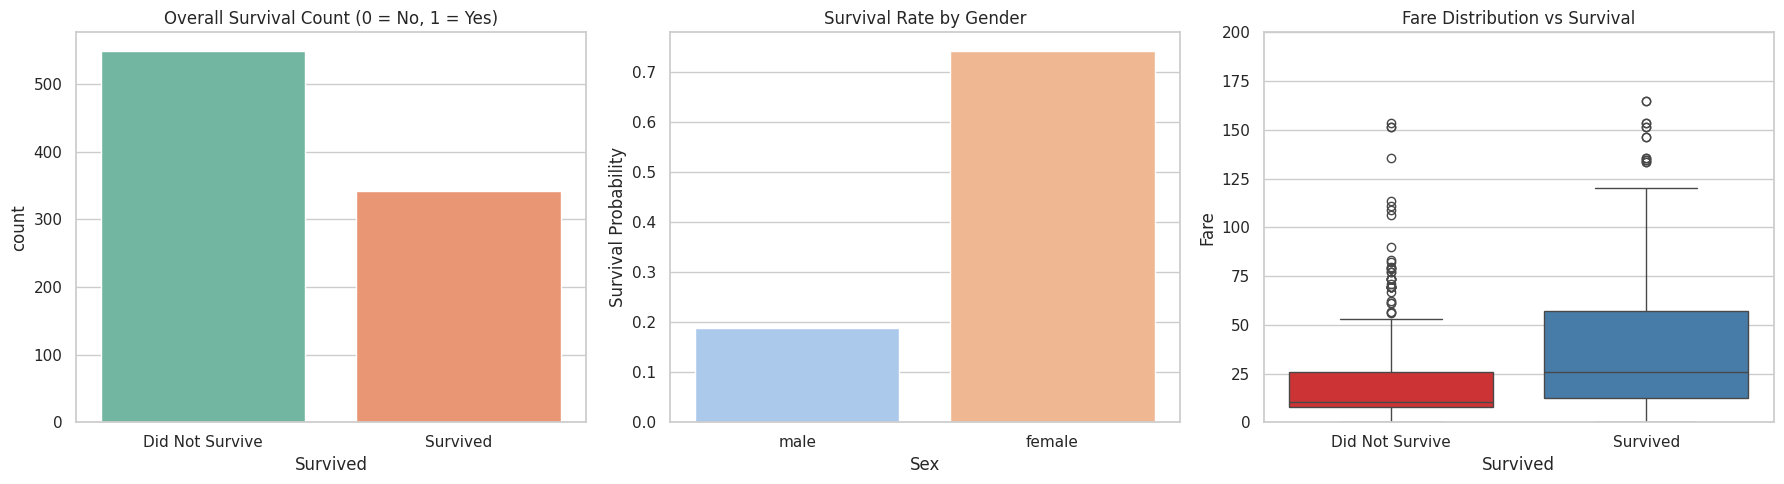

In [ ]:
# Task 5: Exploratory Data Analysis (EDA)

# Statistical Summary
print("--- Statistical Summary ---")
print(df.describe())

# Setup plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Survival Count
sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Overall Survival Count (0 = No, 1 = Yes)')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'])

# Plot 2: Survival Rate by Gender
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[1], palette='pastel', ci=None)
axes[1].set_title('Survival Rate by Gender')
axes[1].set_ylabel('Survival Probability')

# Plot 3: Distribution of Fares paid by Survival Status
sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[2], palette='Set1')
axes[2].set_title('Fare Distribution vs Survival')
axes[2].set_ylim(0, 200) # Limiting y-axis to see the boxes clearly
axes[2].set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

In [ ]:

# Simple manual encoding for Binary Categorical column: Sex
df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding for Nominal Categorical column: Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("--- Dataframe Sample with Encodings ---")
df[['Name', 'Sex', 'Sex_Encoded', 'Embarked_Q', 'Embarked_S']].head()

--- Dataframe Sample with Encodings ---


,Name,Sex,Sex_Encoded,Embarked_Q,Embarked_S
0,"Braund, Mr. Owen Harris",male,0,False,True
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,False,False
2,"Heikkinen, Miss. Laina",female,1,False,True
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,False,True
4,"Allen, Mr. William Henry",male,0,False,True
